# 01. Градиентный бустинг вручную на 6 точках

| | |
|---|---|
| **Уровень** | 1 из 4 — крошечные данные: всё считается вручную (`1_tiny`) |
| **Скрипт-источник** | [`01_boosting_by_hand.py`](../01_boosting_by_hand.py) — тот же код, запуск из терминала |
| **Время выполнения** | ≈ 2 с |

**Цель.** Увидеть весь алгоритм бустинга числами — без библиотек, без «магии».

### Чему вы научитесь

- Стартовая константа F₀
- Остатки
- Выбор лучшего пня перебором
- Значения листьев
- Шаг с темпом ν
- Как ошибка падает от дерева к дереву
- Сверка с `gbcourse`

### Данные

`toy_regression` — 6 объектов, 1 признак x = 1…6, цель y = (2, 4, 3, 7, 9, 11). Специально такой маленький, чтобы каждое число можно было проверить на листке бумаги.

### План

1. **Этап 1.** Данные
2. **Этап 2.** Старт: лучшая константа для квадратичной потери — среднее
3. **Этап 4.** Сверка с gbcourse.GBRegressor (глубина 1, 3 дерева, ν = 0.5)
4. **Этап 5.** Картинка

**Ожидаемый результат.** MSE 10.67 → 3.92 → 1.57 → 0.81; прогнозы совпадают с gbcourse точно (расхождение 0).

> Ноутбук собран из `examples/1_tiny/01_boosting_by_hand.py` командой `python examples/build_notebooks.py`. Чтобы изменить пример, правьте скрипт и пересоберите ноутбук.

## Подготовка

Ячейка ниже находит папку `examples/` (ноутбук можно открыть из любой рабочей папки внутри
репозитория), подключает общий каркас примеров `_common.Example` и учебную библиотеку курса
`gbcourse`. Каркас печатает этапы и выводы, «раскрывает» датасет и показывает графики прямо в
ноутбуке. Выполняйте ячейки сверху вниз: **Run → Run All Cells**.

In [2]:
import sys
from pathlib import Path

EXAMPLES = next(p / "examples" for p in [Path.cwd(), *Path.cwd().parents]
                if (p / "examples" / "_common.py").is_file())
sys.path.insert(0, str(EXAMPLES))
from _common import Example

ex = Example(EXAMPLES / "1_tiny/01_boosting_by_hand.py", title="01. Градиентный бустинг вручную на 6 точках",
             goal="пройти алгоритм бустинга по шагам и проверить каждое число")

import matplotlib.pyplot as plt
import numpy as np
from gbcourse import GBRegressor, datasets

## Этап 1. Данные

In [3]:
X, y = datasets.toy_regression()
x = X[:, 0]
ex.describe(X, y, names=["x"], target="y", source="gbcourse.datasets.toy_regression() — учебный набор курса")

   Источник: gbcourse.datasets.toy_regression() — учебный набор курса
   Объектов: 6   признаков: 1   память: 0.00 МБ
   Типы признаков: float64 × 1
   Пропусков нет
   Цель «y»: среднее 6.000, σ 3.266, мин 2.000, макс 11.000
   Первые строки:


,x,[y]
0,1.0,2.0
1,2.0,4.0
2,3.0,3.0


## Этап 2. Старт: лучшая константа для квадратичной потери — среднее

In [4]:
F = np.full_like(y, y.mean())
print(f"   F₀ = mean(y) = {y.mean():.4f};  MSE = {np.mean((y - F) ** 2):.4f}")

   F₀ = mean(y) = 6.0000;  MSE = 10.6667


In [5]:
LR = 0.5
history = [np.mean((y - F) ** 2)]
trees = []
for m in range(1, 4):
    ex.stage(f"3.{m}", f"Итерация {m}: остатки → лучший пень → шаг ν = {LR}")
    r = y - F                                            # остатки = антиградиент квадратичной потери
    print("   x:        " + "  ".join(f"{v:6.2f}" for v in x))
    print("   y:        " + "  ".join(f"{v:6.2f}" for v in y))
    print("   F:        " + "  ".join(f"{v:6.2f}" for v in F))
    print("   r = y−F:  " + "  ".join(f"{v:+6.2f}" for v in r))
    # Перебираем все пороги между соседними x и считаем сумму квадратов ошибок пня на остатках
    best = None
    print("   порог  | лист слева | лист справа | SSE")
    for k in range(1, len(x)):
        t = (x[k - 1] + x[k]) / 2
        left, right = r[x <= t].mean(), r[x > t].mean()
        sse = np.sum((r[x <= t] - left) ** 2) + np.sum((r[x > t] - right) ** 2)
        print(f"   {t:5.1f}  | {left:+10.3f} | {right:+11.3f} | {sse:7.3f}")
        if best is None or sse < best[0]:
            best = (sse, t, left, right)
    sse, t, left, right = best
    print(f"   лучший пень: x ≤ {t} → {left:+.3f}, иначе {right:+.3f}  (SSE {sse:.3f})")
    h = np.where(x <= t, left, right)
    F = F + LR * h                                       # маленький шаг в сторону пня
    history.append(np.mean((y - F) ** 2))
    trees.append((t, left, right))
    print("   новый F:  " + "  ".join(f"{v:6.2f}" for v in F) + f"   MSE = {history[-1]:.4f}")

ex.note("Ошибка падает с каждым деревом, но не до нуля сразу: темп ν = 0.5 оставляет работу следующим деревьям.")
assert all(a > b for a, b in zip(history, history[1:])), "MSE должна убывать"


▶ Этап 3.1. Итерация 1: остатки → лучший пень → шаг ν = 0.5
   x:          1.00    2.00    3.00    4.00    5.00    6.00
   y:          2.00    4.00    3.00    7.00    9.00   11.00
   F:          6.00    6.00    6.00    6.00    6.00    6.00
   r = y−F:   -4.00   -2.00   -3.00   +1.00   +3.00   +5.00
   порог  | лист слева | лист справа | SSE
     1.5  |     -4.000 |      +0.800 |  44.800
     2.5  |     -3.000 |      +1.500 |  37.000
     3.5  |     -3.000 |      +3.000 |  10.000
     4.5  |     -2.000 |      +4.000 |  16.000
     5.5  |     -1.000 |      +5.000 |  34.000
   лучший пень: x ≤ 3.5 → -3.000, иначе +3.000  (SSE 10.000)
   новый F:    4.50    4.50    4.50    7.50    7.50    7.50   MSE = 3.9167

▶ Этап 3.2. Итерация 2: остатки → лучший пень → шаг ν = 0.5
   x:          1.00    2.00    3.00    4.00    5.00    6.00
   y:          2.00    4.00    3.00    7.00    9.00   11.00
   F:          4.50    4.50    4.50    7.50    7.50    7.50
   r = y−F:   -2.50   -0.50   -1.50   -0.50 

> ▸ **Вывод.** Ошибка падает с каждым деревом, но не до нуля сразу: темп ν = 0.5 оставляет работу следующим деревьям.

## Этап 4. Сверка с gbcourse.GBRegressor (глубина 1, 3 дерева, ν = 0.5)

In [5]:
lib = GBRegressor(n_estimators=3, learning_rate=LR, max_depth=1).fit(X, y)
diff = np.abs(lib.predict(X) - F).max()
print(f"   наибольшее расхождение прогнозов: {diff:.1e}")
assert diff < 1e-12
ex.note("Библиотека делает ровно то же самое, что мы посчитали руками.")

   наибольшее расхождение прогнозов: 0.0e+00


> ▸ **Вывод.** Библиотека делает ровно то же самое, что мы посчитали руками.

## Этап 5. Картинка

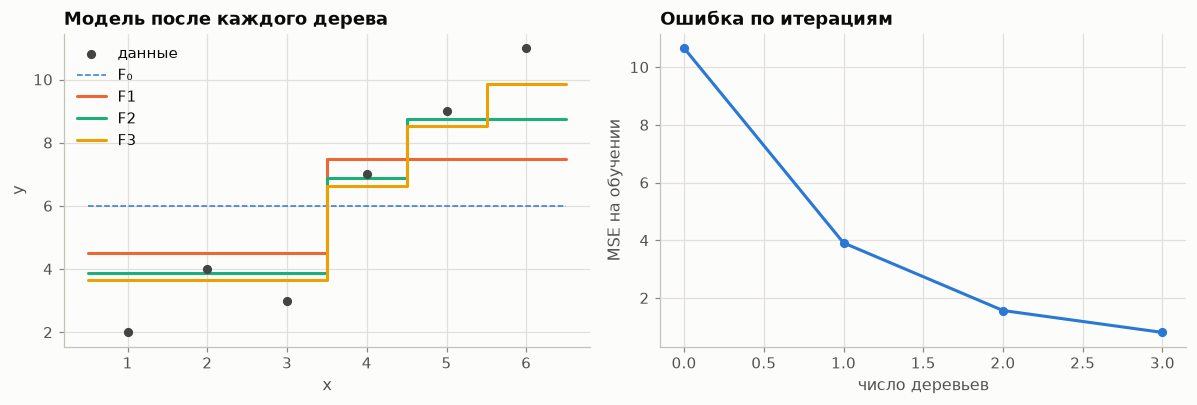

Готово за 0.4 с


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
grid = np.linspace(0.5, 6.5, 300)
axes[0].scatter(x, y, color="#444", zorder=3, label="данные")
Fg = np.full_like(grid, y.mean())
axes[0].plot(grid, Fg, lw=1, ls="--", label="F₀")
for m, (t, left, right) in enumerate(trees, 1):
    Fg = Fg + LR * np.where(grid <= t, left, right)
    axes[0].step(grid, Fg, where="mid", lw=2, label=f"F{m}")
axes[0].set(xlabel="x", ylabel="y", title="Модель после каждого дерева")
axes[0].legend()
axes[1].plot(range(len(history)), history, marker="o")
axes[1].set(xlabel="число деревьев", ylabel="MSE на обучении", title="Ошибка по итерациям")
fig.tight_layout()
ex.finish(fig, "01_boosting_by_hand")
ex.done()

## Попробуйте сами

Измените код в ячейках выше и выполните их заново:

1. Поставьте LR = 1.0: за сколько итераций MSE станет почти нулевой и почему на новых данных это плохо?
2. После загрузки данных сделайте y[5] = 30 (выброс) и проследите, как он перетягивает пороги и значения листьев.
3. Добавьте четвёртую итерацию, проверьте её числа на листке и сверьте с `GBRegressor(n_estimators=4)`.

## Что дальше

- **Теория в курсе:** [4.1 «Остатки вручную»](../../../lessons/lesson_4_1/README.md), [2.1 «Пень»](../../../lessons/lesson_2_1/README.md).
- **Следующий пример:** [02. Дерево решений вручную: 10 объектов, 2 признака](02_tree_by_hand.ipynb)
- **Все примеры:** [examples/README.md](../../README.md)